In [32]:
!pip install pynhd pygeohydro pygeoogc geopandas matplotlib

In [ ]:
# test_flow_direction.ipynb

import os
import numpy as np
import rasterio
from pysheds.grid import Grid
import matplotlib.pyplot as plt

# === CONFIGURATION ===
dem_path = "/u/nathanj/national_ml/data/script/gee_downloads/HUC8_10020007_Madison/HUC8_10020007_Madison_DEM_10m_Rect.tif"  # Replace with your test DEM
output_path = dem_path.replace('.tif', '_flow_direction.tif')
temp_dem_path = dem_path.replace('.tif', '_corrected.tif')

# === STEP 1: Load and preprocess DEM ===
with rasterio.open(dem_path) as src:
    profile = src.profile
    dem_array = src.read(1)

    # Determine a valid nodata value based on dtype
    dtype = dem_array.dtype
    if np.issubdtype(dtype, np.unsignedinteger):
        nodata_val = 65535
    elif np.issubdtype(dtype, np.floating):
        nodata_val = np.nan
    else:
        nodata_val = -32767

    # Optional: Mask extreme or invalid values
    dem_array = np.where(np.isnan(dem_array) | (dem_array <= -9999), nodata_val, dem_array)
    
    # Update profile
    profile.update(nodata=nodata_val)

    # Save corrected DEM to a temporary file
    with rasterio.open(temp_dem_path, 'w', **profile) as dst:
        dst.write(dem_array, 1)

print(f"      - Corrected DEM saved to: {temp_dem_path}")

      - Corrected DEM saved to: /u/nathanj/national_ml/data/script/gee_downloads/HUC8_10020007_Madison/HUC8_10020007_Madison_DEM_10m_Rect_corrected.tif


In [ ]:

# === STEP 2: Use PySheds to compute flow direction ===
try:
    print("Loading DEM into PySheds Grid...")
    grid = Grid.from_raster(temp_dem_path)
    dem = grid.read_raster(temp_dem_path)

    print("Filling pits...")
    pit_filled_dem = grid.fill_pits(dem)
    
    print("Filling depressions...")
    flooded_dem = grid.fill_depressions(pit_filled_dem)

    print("Resolving flats...")
    inflated_dem = grid.resolve_flats(flooded_dem)

    print("Calculating D8 flow direction...")
    dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
    fdir = grid.flowdir(inflated_dem, dirmap=dirmap, nodata_out = np.int32(-1))

    print(f"Saving D8 flow direction to: {output_path}")
    grid.to_raster(fdir, output_path)

except Exception as e:
    print(f"PySheds Error: {e}")
# finally:
#     if os.path.exists(temp_dem_path):
#         os.remove(temp_dem_path)
#         print(f"Deleted temp file: {temp_dem_path}")

# # === STEP 3: Visualize result ===
# with rasterio.open(output_path) as src:
#     flow_dir_array = src.read(1)
#     plt.figure(figsize=(10, 8))
#     plt.title("D8 Flow Direction")
#     plt.imshow(flow_dir_array, cmap='viridis')
#     plt.colorbar(label="Flow Direction Code")
#     plt.show()


Loading DEM into PySheds Grid...
Filling pits...
Filling depressions...
Resolving flats...
Calculating D8 flow direction...
Saving D8 flow direction to: /u/nathanj/national_ml/data/script/gee_downloads/HUC8_10020007_Madison/HUC8_10020007_Madison_DEM_10m_Rect_flow_direction.tif


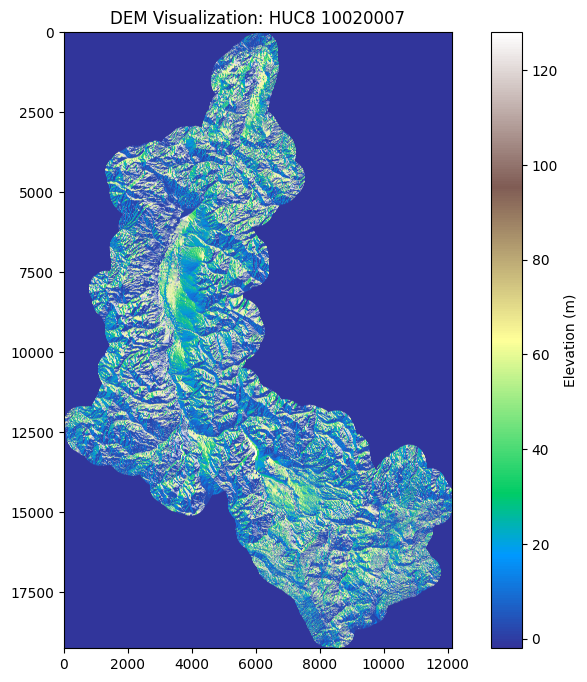

In [34]:
import rasterio
with rasterio.open("/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/flow_direction.tif") as src_vis:
    dem_vis = src_vis.read(1)
    plt.figure(figsize=(10, 8))
    plt.title("DEM Visualization: HUC8 10020007")
    plt.imshow(dem_vis, cmap='terrain')
    plt.colorbar(label="Elevation (m)")
    plt.show()

In [20]:
import geopandas as gpd

# Paths
gdb_path = "/u/nathanj/national_ml/data/raw/nhdplus_gdb/NHDPlus_H_National_Release_2.gdb"
huc8_path = "/u/nathanj/national_ml/data/processed/huc_processing/03040206/huc8_03040206_boundary.geojson"

# Load HUC8 boundary
huc8 = gpd.read_file(huc8_path).to_crs("EPSG:4269")
bbox = tuple(huc8.total_bounds)

# Define layers to extract
layers = {
    "NetworkNHDFlowline": "flowlines_network_10020007.gpkg",
    "NonNetworkNHDFlowline": "flowlines_non_network_10020007.gpkg",
    "NHDWaterbody": "waterbodies_10020007.gpkg"
}

# Process each layer
for layer_name, output_file in layers.items():
    print(f"Processing {layer_name}...")
    gdf = gpd.read_file(gdb_path, layer=layer_name, bbox=bbox)
    gdf_clipped = gdf[gdf.intersects(huc8.unary_union)]
    gdf_clipped.to_file(output_file, driver="GPKG")
    print(f"Saved to {output_file}")


Processing NetworkNHDFlowline...


/u/nathanj/miniconda3/envs/pytorch_gpu_cu118/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(
/tmp/ipykernel_3266612/1241736695.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_clipped = gdf[gdf.intersects(huc8.unary_union)]


Saved to flowlines_network_10020007.gpkg
Processing NonNetworkNHDFlowline...


/u/nathanj/miniconda3/envs/pytorch_gpu_cu118/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(
/tmp/ipykernel_3266612/1241736695.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_clipped = gdf[gdf.intersects(huc8.unary_union)]


Saved to flowlines_non_network_10020007.gpkg
Processing NHDWaterbody...


/tmp/ipykernel_3266612/1241736695.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_clipped = gdf[gdf.intersects(huc8.unary_union)]


Saved to waterbodies_10020007.gpkg


/tmp/ipykernel_3266612/4168739088.py:10: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


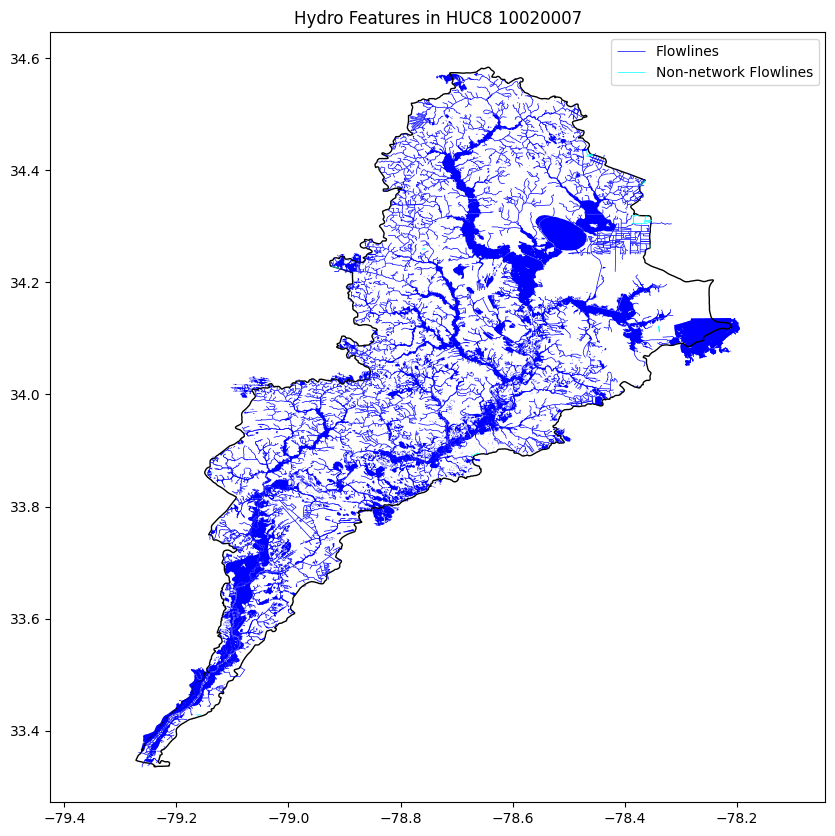

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
huc8.boundary.plot(ax=ax, color="black", linewidth=1)
gpd.read_file("flowlines_network_10020007.gpkg").plot(ax=ax, color="blue", linewidth=0.5, label="Flowlines")
gpd.read_file("flowlines_non_network_10020007.gpkg").plot(ax=ax, color="cyan", linewidth=0.5, label="Non-network Flowlines")
gpd.read_file("waterbodies_10020007.gpkg").plot(ax=ax, color="blue", label="Waterbodies")
plt.title("Hydro Features in HUC8 10020007")
plt.axis("equal")
plt.legend()
plt.show()


In [28]:
import geopandas as gpd
import rasterio
from rasterio import features
import numpy as np
import pandas as pd
import os

# === Inputs ===
gdb_path = "/u/nathanj/national_ml/data/raw/nhdplus_gdb/NHDPlus_H_National_Release_2.gdb"
huc8_path = "/u/nathanj/national_ml/data/script/pipeline_output/huc_processing/10020007/huc8_10020007_boundary.geojson"
template_raster_path = "/u/nathanj/national_ml/data/script/pipeline_output/huc_processing/10020007/huc8_10020007_dem.tif"
output_raster_path = "hydro_mask_10020007.tif"
buffer_distance = 15  # meters

# === Step 1: Load HUC8 boundary ===
huc8 = gpd.read_file(huc8_path).to_crs("EPSG:4269")
bbox = tuple(huc8.total_bounds)

# === Step 2: Read & clip NHD layers ===
layers = ["NetworkNHDFlowline", "NonNetworkNHDFlowline", "NHDWaterbody"]
combined_gdfs = []

for layer in layers:
    print(f"Reading and clipping {layer}...")
    gdf = gpd.read_file(gdb_path, layer=layer, bbox=bbox).to_crs("EPSG:4269")
    gdf_clipped = gdf[gdf.intersects(huc8.unary_union)]
    combined_gdfs.append(gdf_clipped)

# === Step 3: Combine & Buffer ===
print("Combining layers and buffering 15m...")
combined_gdf = gpd.GeoDataFrame(pd.concat(combined_gdfs, ignore_index=True), crs="EPSG:4269")

# Reproject to match raster CRS (e.g., DEM CRS)
with rasterio.open(template_raster_path) as src:
    raster_crs = src.crs
    raster_transform = src.transform
    raster_shape = (src.height, src.width)

combined_gdf = combined_gdf.to_crs(raster_crs)
buffered = combined_gdf.buffer(buffer_distance)

# === Step 4: Rasterize ===
print("Rasterizing buffered features...")
mask = features.rasterize(
    ((geom, 1) for geom in buffered if geom is not None and geom.is_valid),
    out_shape=raster_shape,
    transform=raster_transform,
    fill=0,
    dtype="uint8"
)

# === Step 5: Save Raster ===
print(f"Saving raster to: {output_raster_path}")
meta = src.meta.copy()
meta.update({
    'dtype': 'uint8',
    'count': 1,
    'compress': 'lzw',
    'nodata': 0
})

with rasterio.open(output_raster_path, 'w', **meta) as dst:
    dst.write(mask, 1)

print("✅ Done.")

Reading and clipping NetworkNHDFlowline...


/u/nathanj/miniconda3/envs/pytorch_gpu_cu118/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(
/tmp/ipykernel_3203544/2099679527.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_clipped = gdf[gdf.intersects(huc8.unary_union)]


Reading and clipping NonNetworkNHDFlowline...
Reading and clipping NHDWaterbody...


/u/nathanj/miniconda3/envs/pytorch_gpu_cu118/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(
/tmp/ipykernel_3203544/2099679527.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_clipped = gdf[gdf.intersects(huc8.unary_union)]
/tmp/ipykernel_3203544/2099679527.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_clipped = gdf[gdf.intersects(huc8.unary_union)]


Combining layers and buffering 15m...
Rasterizing buffered features...
Saving raster to: hydro_mask_10020007.tif
✅ Done.


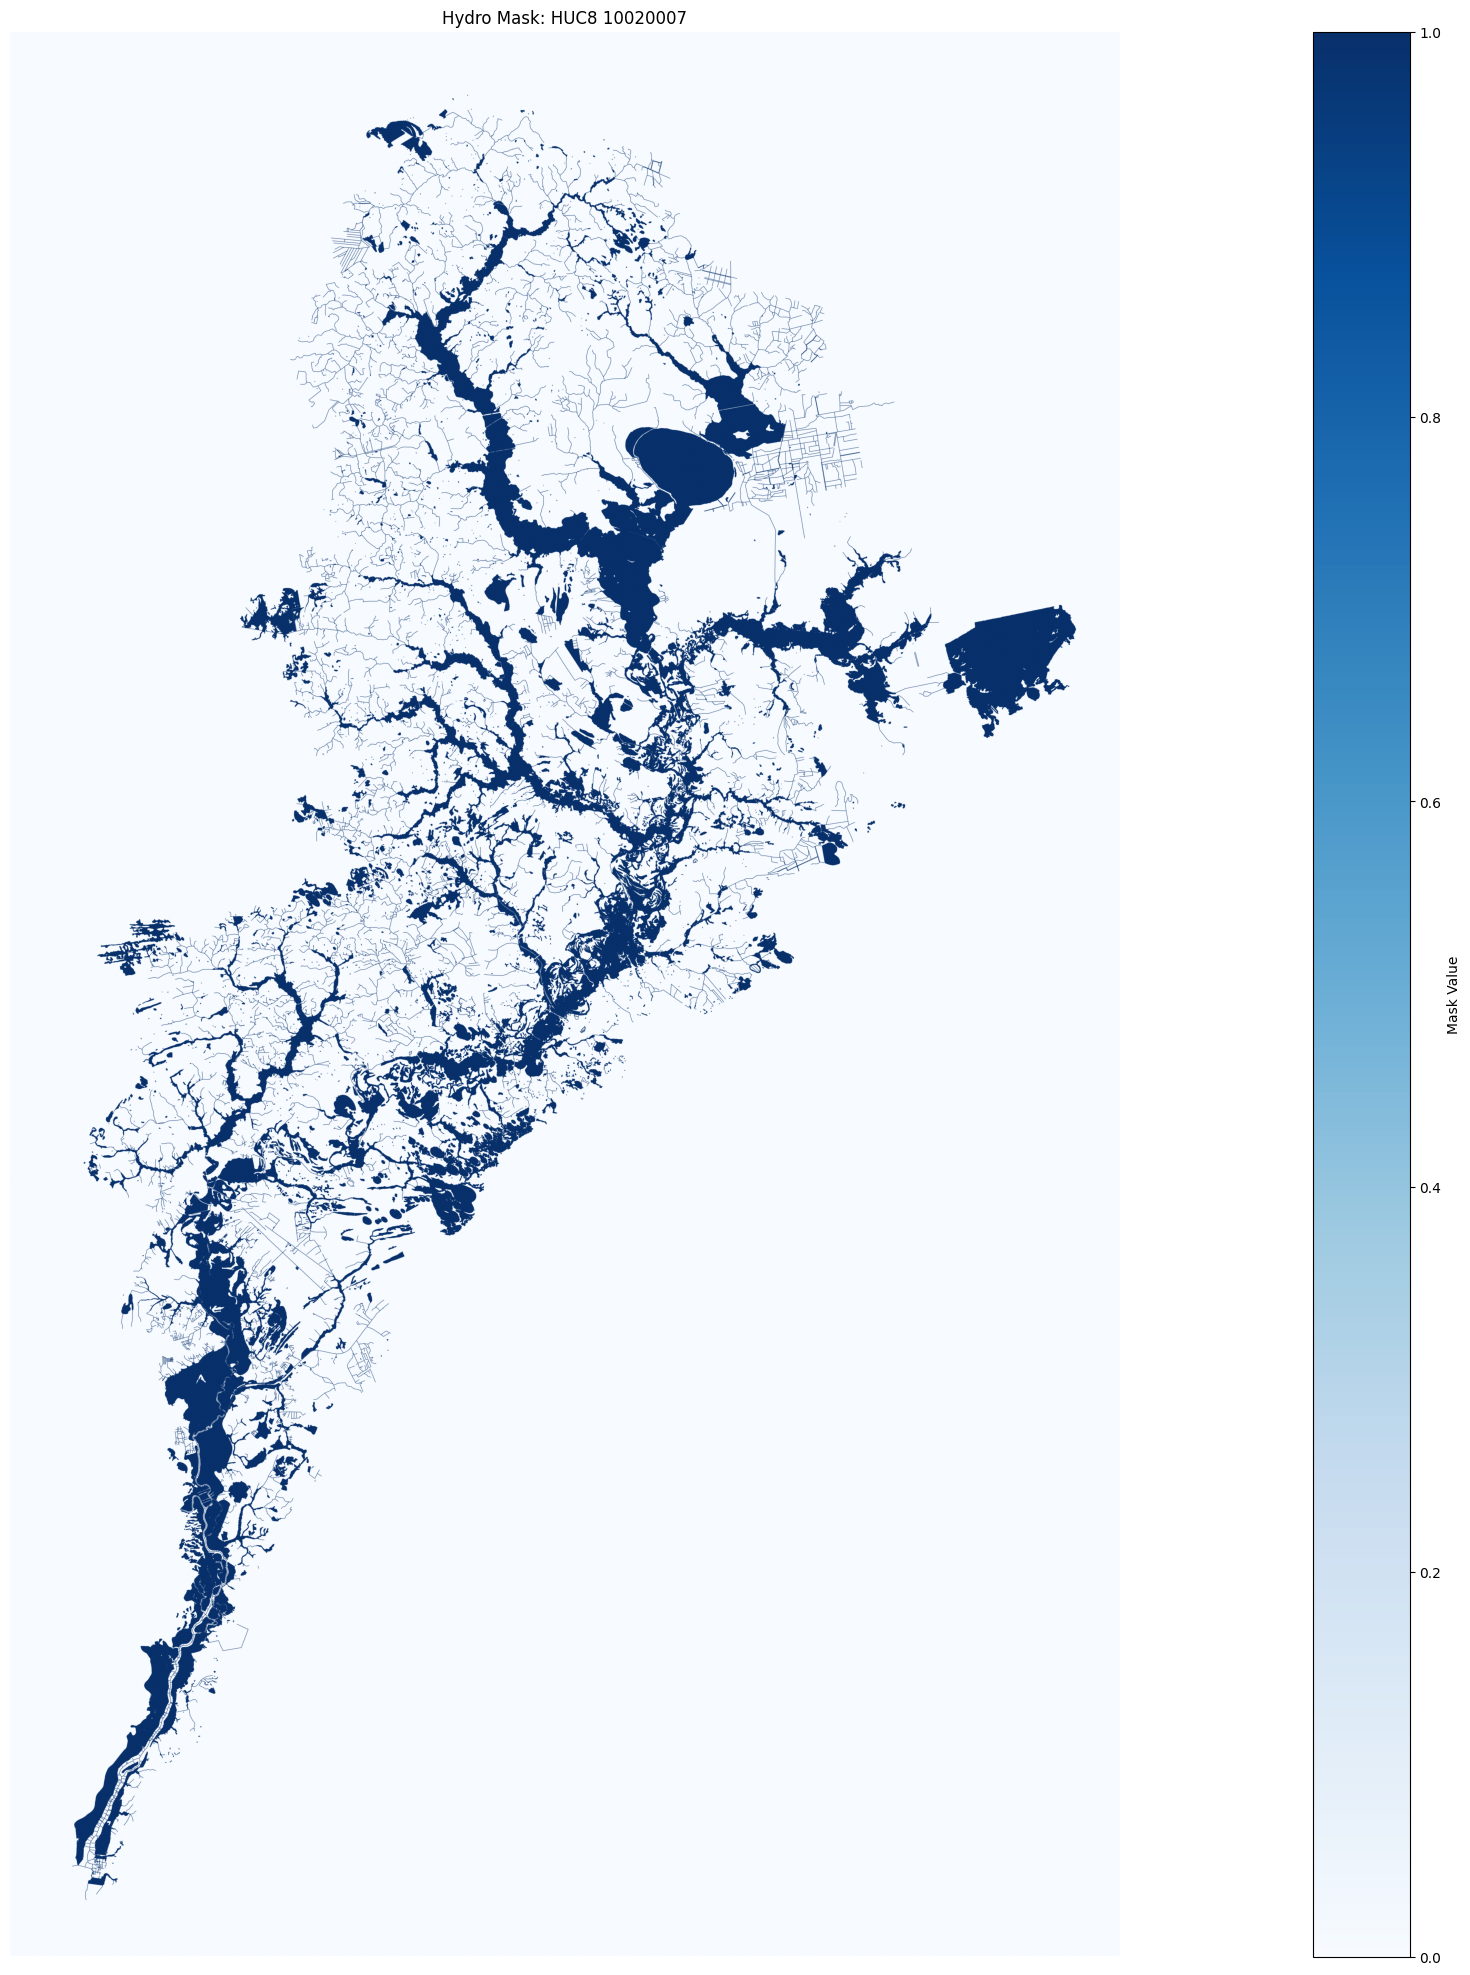

In [19]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("/u/nathanj/national_ml/data/processed/patch_dataset/03040206/hydro_mask.tif") as src_mask:
    hydro_mask = src_mask.read(1)
    plt.figure(figsize=(50,25))
    plt.title("Hydro Mask: HUC8 10020007")
    plt.imshow(hydro_mask, cmap="Blues")
    plt.colorbar(label="Mask Value")
    plt.axis("off")
    plt.show()

In [ ]:
import rasterio

# File paths
full_raster_path = "/u/nathanj/national_ml/data/processed/patch_dataset/03040206/hydro_mask.tif"
patch_template_path = "/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/patch_1314_georef_template.tif"

# Open the rasters
with rasterio.open(full_raster_path) as full_src, rasterio.open(patch_template_path) as patch_src:
    full_crs = full_src.crs
    patch_crs = patch_src.crs

    # Display CRS
    print("=== CRS Comparison ===")
    print(f"Full raster CRS:    {full_crs}")
    print(f"Patch template CRS: {patch_crs}")
    
    # Compare
    if full_crs == patch_crs:
        print("\n✅ CRS MATCHES — No reprojection needed.")
    else:
        print("\n❌ CRS MISMATCH — Reprojection is required.")

=== CRS Comparison ===
Full raster CRS:    EPSG:5070
Patch template CRS: EPSG:5070

✅ CRS MATCHES — No reprojection needed.


In [3]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
import os

def visualize_dem_vs_hydro_mask(patch_template_path, patch_npz_path, hydro_mask_path):
    # Step 1: Load DEM patch from .npz
    with np.load(patch_npz_path) as data:
        dem_patch = data['dem']
    
    # Step 2: Open hydro_mask raster and patch template
    with rasterio.open(hydro_mask_path) as hydro_src, rasterio.open(patch_template_path) as template_src:
        hydro_crs = hydro_src.crs
        template_crs = template_src.crs
        
        # Step 3: Reproject template if CRS mismatch
        if hydro_crs != template_crs:
            print("⚠️ CRS mismatch. Reprojecting patch template to match hydro_mask CRS...")

            reprojected_path = patch_template_path.replace(".tif", "_reprojected_tmp.tif")
            transform, width, height = calculate_default_transform(
                template_crs, hydro_crs, template_src.width, template_src.height, *template_src.bounds)
            
            kwargs = template_src.meta.copy()
            kwargs.update({
                'crs': hydro_crs,
                'transform': transform,
                'width': width,
                'height': height
            })

            with rasterio.open(reprojected_path, 'w', **kwargs) as dst:
                for i in range(1, template_src.count + 1):
                    reproject(
                        source=rasterio.band(template_src, i),
                        destination=rasterio.band(dst, i),
                        src_transform=template_src.transform,
                        src_crs=template_src.crs,
                        dst_transform=transform,
                        dst_crs=hydro_crs,
                        resampling=Resampling.nearest
                    )
            
            template_path_for_window = reprojected_path
        else:
            template_path_for_window = patch_template_path

        # Step 4: Extract hydro mask patch
        with rasterio.open(template_path_for_window) as aligned_template:
            window = hydro_src.window(*aligned_template.bounds)
            hydro_patch = hydro_src.read(1, window=window)
    
    # Step 5: Visualization
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.title("DEM Patch from .npz")
    plt.imshow(dem_patch, cmap='terrain')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.title("Extracted Hydro Mask Patch")
    plt.imshow(hydro_patch, cmap='Blues')
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    # Cleanup reprojected file
    if 'reprojected_path' in locals() and os.path.exists(reprojected_path):
        os.remove(reprojected_path)


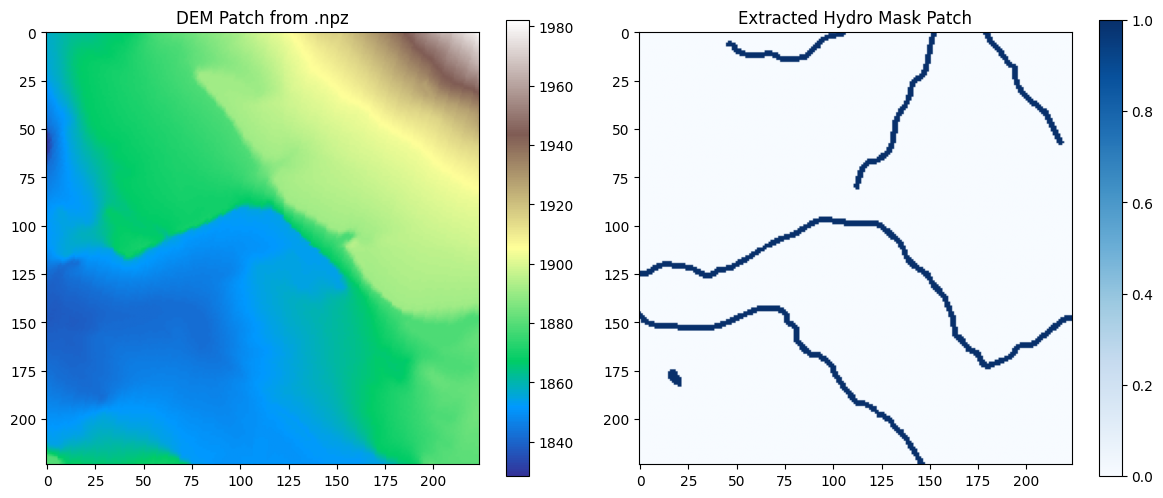

In [4]:
visualize_dem_vs_hydro_mask(
    patch_template_path="/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/patch_1313_georef_template.tif",
    patch_npz_path="/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/patch_1313.npz",
    hydro_mask_path="/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/hydro_mask.tif"
)

In [5]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
import os

def visualize_dem_with_hydro_mask_overlay(patch_template_path, patch_npz_path, hydro_mask_path):
    # Step 1: Load DEM patch from .npz
    with np.load(patch_npz_path) as data:
        dem_patch = data['dem']
    
    # Step 2: Open hydro_mask raster and patch template
    with rasterio.open(hydro_mask_path) as hydro_src, rasterio.open(patch_template_path) as template_src:
        hydro_crs = hydro_src.crs
        template_crs = template_src.crs
        
        # Step 3: Reproject template if CRS mismatch
        if hydro_crs != template_crs:
            print("⚠️ CRS mismatch. Reprojecting patch template to match hydro_mask CRS...")

            reprojected_path = patch_template_path.replace(".tif", "_reprojected_tmp.tif")
            transform, width, height = calculate_default_transform(
                template_crs, hydro_crs, template_src.width, template_src.height, *template_src.bounds)
            
            kwargs = template_src.meta.copy()
            kwargs.update({
                'crs': hydro_crs,
                'transform': transform,
                'width': width,
                'height': height
            })

            with rasterio.open(reprojected_path, 'w', **kwargs) as dst:
                for i in range(1, template_src.count + 1):
                    reproject(
                        source=rasterio.band(template_src, i),
                        destination=rasterio.band(dst, i),
                        src_transform=template_src.transform,
                        src_crs=template_src.crs,
                        dst_transform=transform,
                        dst_crs=hydro_crs,
                        resampling=Resampling.nearest
                    )
            
            template_path_for_window = reprojected_path
        else:
            template_path_for_window = patch_template_path

        # Step 4: Extract hydro mask patch
        with rasterio.open(template_path_for_window) as aligned_template:
            window = hydro_src.window(*aligned_template.bounds)
            hydro_patch = hydro_src.read(1, window=window)
    
    # Step 5: Visualization - Overlay
    plt.figure(figsize=(6, 6))
    plt.title("Hydro Mask Overlay on DEM")
    plt.imshow(dem_patch, cmap='terrain')
    plt.imshow(hydro_patch, cmap='Blues', alpha=0.4)
    plt.colorbar(label="Hydro Mask")
    plt.tight_layout()
    plt.show()

    # Cleanup reprojected file
    if 'reprojected_path' in locals() and os.path.exists(reprojected_path):
        os.remove(reprojected_path)


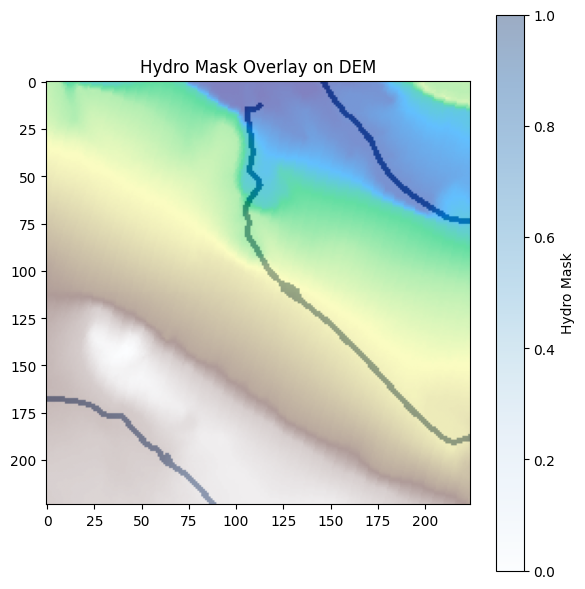

In [6]:
visualize_dem_with_hydro_mask_overlay(
    patch_template_path="/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/patch_1312_georef_template.tif",
    patch_npz_path="/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/patch_1312.npz",
    hydro_mask_path="/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/hydro_mask.tif"
)


In [7]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
import os

def visualize_dem_with_hydro_mask_overlay(patch_template_path, patch_npz_path, hydro_mask_path):
    # Step 1: Load DEM patch from .npz
    with np.load(patch_npz_path) as data:
        dem_patch = data['dem']
    target_shape = dem_patch.shape
    
    # Step 2: Open hydro_mask raster and patch template
    with rasterio.open(hydro_mask_path) as hydro_src, rasterio.open(patch_template_path) as template_src:
        hydro_crs = hydro_src.crs
        template_crs = template_src.crs

        # Step 3: Reproject template if CRS mismatch
        if hydro_crs != template_crs:
            print("⚠️ CRS mismatch. Reprojecting patch template to match hydro_mask CRS...")
            reprojected_path = patch_template_path.replace(".tif", "_reprojected_tmp.tif")
            transform, width, height = calculate_default_transform(
                template_crs, hydro_crs, template_src.width, template_src.height, *template_src.bounds)
            
            kwargs = template_src.meta.copy()
            kwargs.update({
                'crs': hydro_crs,
                'transform': transform,
                'width': width,
                'height': height
            })

            with rasterio.open(reprojected_path, 'w', **kwargs) as dst:
                for i in range(1, template_src.count + 1):
                    reproject(
                        source=rasterio.band(template_src, i),
                        destination=rasterio.band(dst, i),
                        src_transform=template_src.transform,
                        src_crs=template_src.crs,
                        dst_transform=transform,
                        dst_crs=hydro_crs,
                        resampling=Resampling.nearest
                    )
            template_path_for_window = reprojected_path
        else:
            template_path_for_window = patch_template_path

        # Step 4: Extract hydro mask patch
        with rasterio.open(template_path_for_window) as aligned_template:
            window = hydro_src.window(*aligned_template.bounds)
            hydro_patch = hydro_src.read(1, window=window)

    # Step 5: Fix shape mismatch
    if hydro_patch.shape != target_shape:
        print(f"⚠️ Shape mismatch: hydro_mask {hydro_patch.shape} vs DEM {target_shape}. Cropping to match.")
        min_rows = min(hydro_patch.shape[0], target_shape[0])
        min_cols = min(hydro_patch.shape[1], target_shape[1])
        hydro_patch = hydro_patch[:min_rows, :min_cols]
        dem_patch = dem_patch[:min_rows, :min_cols]

    # Step 6: Visualization - Overlay
    plt.figure(figsize=(6, 6))
    plt.title("Hydro Mask Overlay on DEM")
    plt.imshow(dem_patch, cmap='terrain')
    plt.imshow(hydro_patch, cmap='Blues', alpha=0.4)
    plt.colorbar(label="Hydro Mask")
    plt.tight_layout()
    plt.show()

    # Cleanup
    if 'reprojected_path' in locals() and os.path.exists(reprojected_path):
        os.remove(reprojected_path)


⚠️ Shape mismatch: hydro_mask (224, 133) vs DEM (224, 224). Cropping to match.


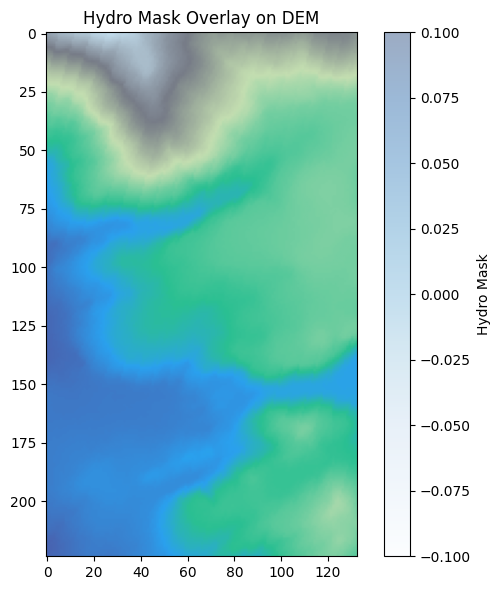

In [8]:
visualize_dem_with_hydro_mask_overlay(
    patch_template_path="/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/patch_0_georef_template.tif",
    patch_npz_path="/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/patch_0.npz",
    hydro_mask_path="/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/hydro_mask.tif"
)


✅ Hydro mask patch shape: (224, 224)
✅ DEM patch shape: (224, 224)


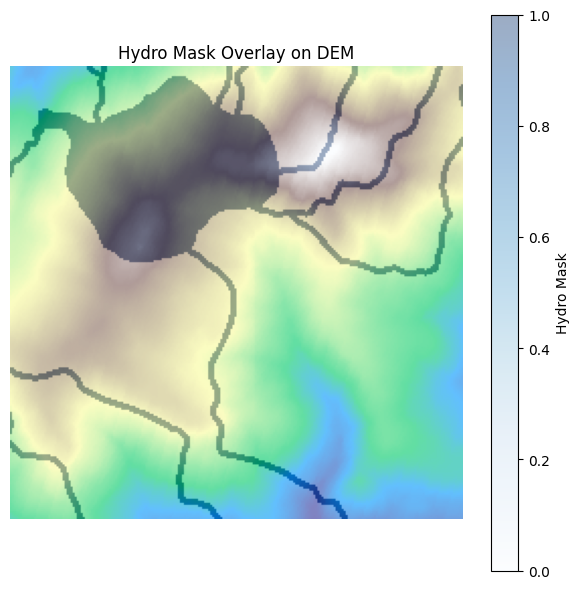

In [16]:
import numpy as np
import rasterio
from rasterio.windows import from_bounds
from pyproj import Transformer
import matplotlib.pyplot as plt

# === Step 1: Set Inputs ===
lat = 44.746872599409066
lon = -110.55288806170795
name = "patch_10020007_5185777437600093"

patch_size = 224   # pixels
scale = 10         # meters/pixel
half_size_m = patch_size * scale / 2

hydro_mask_path = "/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/hydro_mask.tif"
npz_path = "/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/patch_1.npz"

# === Step 2: Load hydro_mask and extract patch ===
with rasterio.open(hydro_mask_path) as src:
    raster_crs = src.crs
    
    # Reproject lat/lon to raster CRS
    transformer = Transformer.from_crs("EPSG:4269", raster_crs, always_xy=True)
    x_center, y_center = transformer.transform(lon, lat)
    
    # Calculate bounding box in projected meters
    xmin, xmax = x_center - half_size_m, x_center + half_size_m
    ymin, ymax = y_center - half_size_m, y_center + half_size_m
    
    # Define raster window and read patch
    window = from_bounds(xmin, ymin, xmax, ymax, src.transform)
    hydro_patch = src.read(1, window=window)

print("✅ Hydro mask patch shape:", hydro_patch.shape)

# === Step 3: Load DEM from NPZ ===
with np.load(npz_path) as data:
    dem_patch = data['dem']
print("✅ DEM patch shape:", dem_patch.shape)

# === Step 4: Match shape if necessary ===
min_rows = min(hydro_patch.shape[0], dem_patch.shape[0])
min_cols = min(hydro_patch.shape[1], dem_patch.shape[1])
hydro_patch = hydro_patch[:min_rows, :min_cols]
dem_patch = dem_patch[:min_rows, :min_cols]

# === Step 5: Visualize ===
plt.figure(figsize=(6, 6))
plt.title("Hydro Mask Overlay on DEM")
plt.imshow(dem_patch, cmap='terrain')
plt.imshow(hydro_patch, cmap='Blues', alpha=0.4)
plt.colorbar(label="Hydro Mask")
plt.axis('off')
plt.tight_layout()
plt.show()


DEM CRS: EPSG:5070
Hydro mask CRS: EPSG:5070


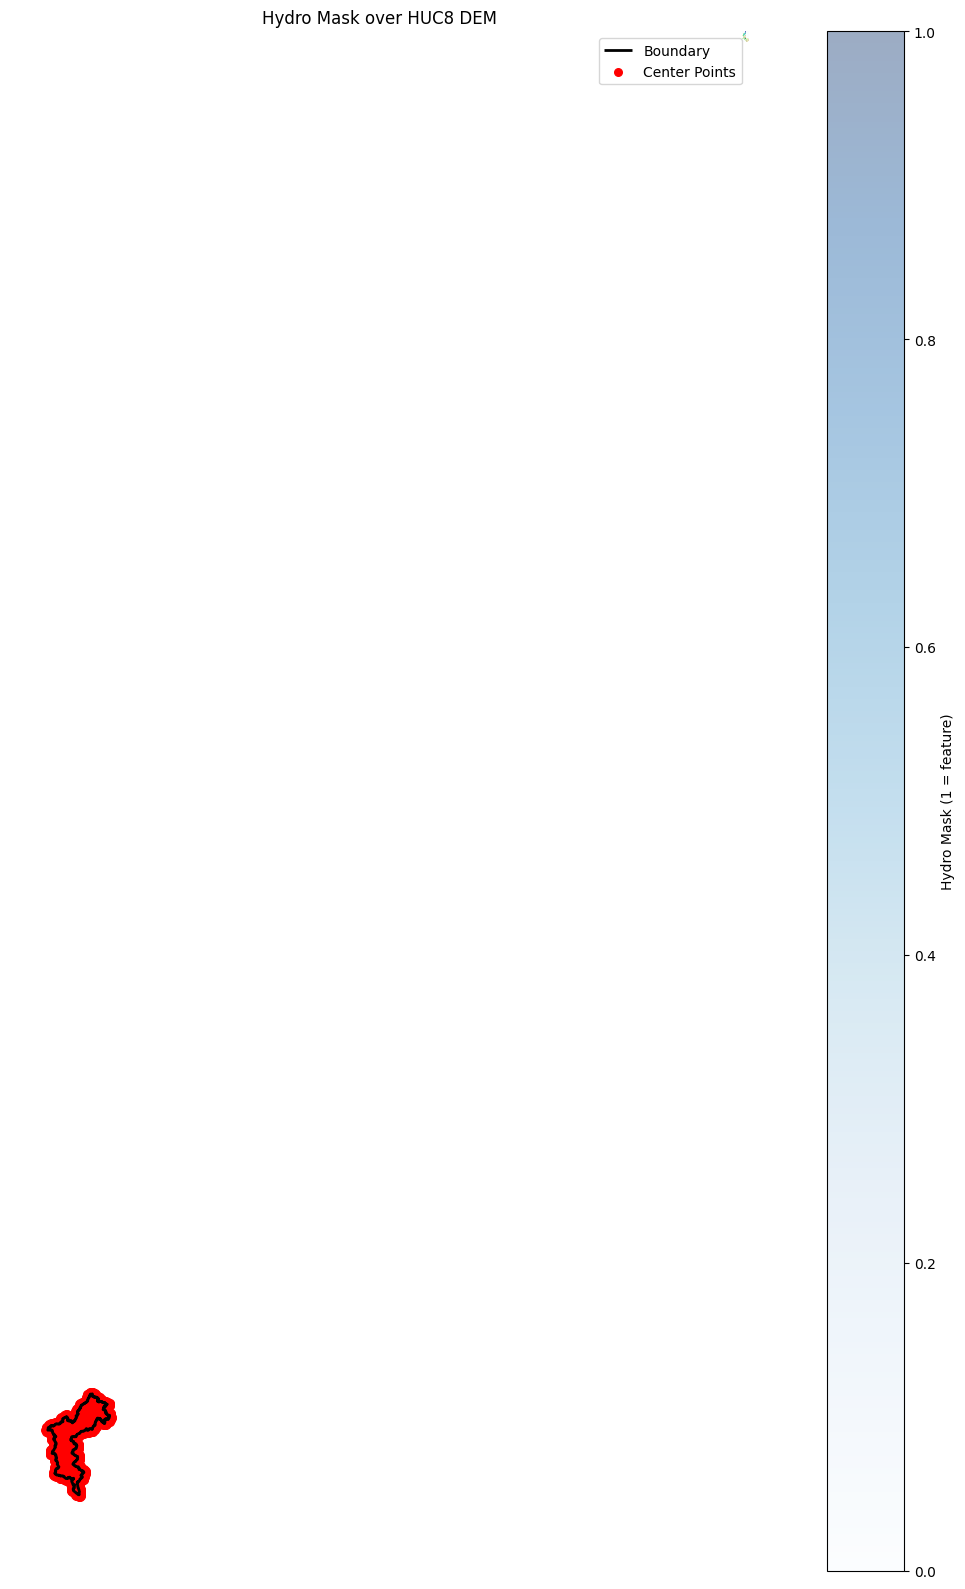

In [12]:
import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
center_points_gdf = gpd.read_file("/u/nathanj/national_ml/data/script/pipeline_output/huc_processing/10020007/huc8_10020007_center_points_features.geojson")
boundary_gdf = gpd.read_file("/u/nathanj/national_ml/data/script/pipeline_output/huc_processing/10020007/huc8_10020007_boundary.geojson")
# === File paths ===
dem_path = "/u/nathanj/national_ml/data/script/pipeline_output/huc_processing/10020007/huc8_10020007_dem.tif"
hydro_mask_path = "/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset/10020007/hydro_mask.tif"

# === Load DEM and hydro mask ===
with rasterio.open(dem_path) as dem_src:
    dem = dem_src.read(1)
    dem_bounds = dem_src.bounds
    dem_crs = dem_src.crs
    transform = dem_src.transform

with rasterio.open(hydro_mask_path) as mask_src:
    hydro_mask = mask_src.read(1)
    mask_crs = mask_src.crs
    mask_bounds = mask_src.bounds

# === Check if CRS matches ===
print("DEM CRS:", dem_crs)
print("Hydro mask CRS:", mask_crs)

if dem_crs != mask_crs:
    print("❌ CRS mismatch detected. Reprojection required.")
else:
    # === Overlay plot ===
    fig, ax = plt.subplots(figsize=(16, 16))
    plt.title("Hydro Mask over HUC8 DEM")

    im1 = ax.imshow(dem, cmap='terrain')
    im2 = ax.imshow(hydro_mask, cmap='Blues', alpha=0.4)
    boundary_gdf.to_crs(dem_crs).boundary.plot(ax=ax, color='black', linewidth=2, label='Boundary')
    center_points_gdf.to_crs(dem_crs).plot(ax=ax, color='red', markersize=30, label='Center Points')

    plt.colorbar(im2, ax=ax, label='Hydro Mask (1 = feature)')
    plt.axis('off')
    plt.legend()
    plt.tight_layout()
    plt.show()


CRS: EPSG:4269
Width: 224
Height: 224


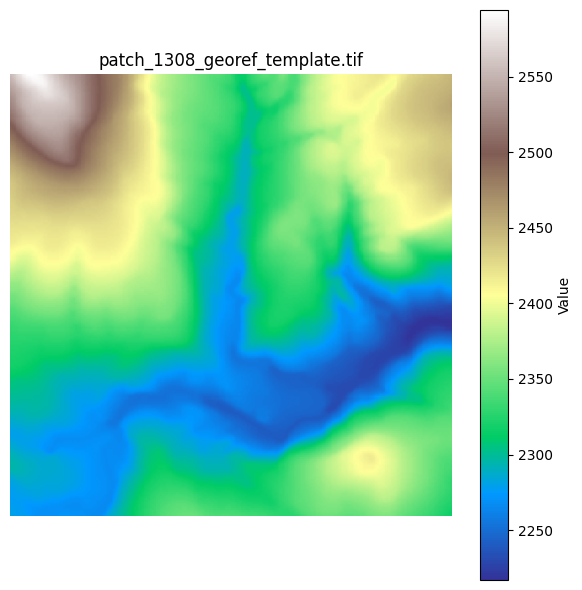

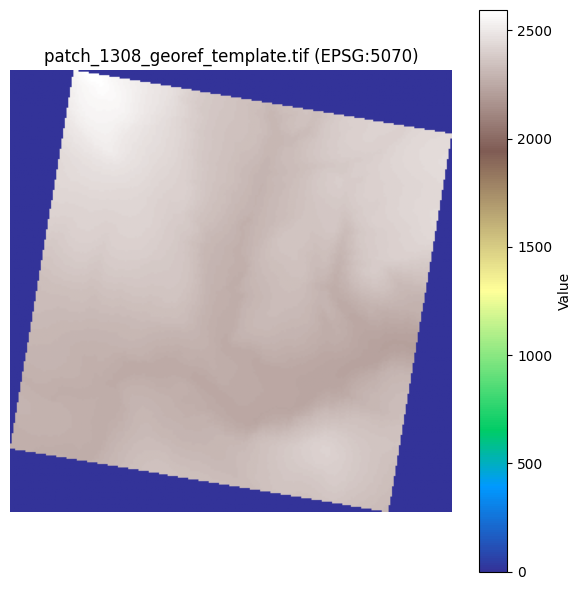

In [15]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject

import matplotlib.pyplot as plt

template_path = "/u/nathanj/national_ml/data/script/pipeline_output/patch_dataset__/10020007/patch_1306_georef_template.tif"

with rasterio.open(template_path) as src:
    arr = src.read(1)
    crs = src.crs
    width = src.width
    height = src.height

    print("CRS:", crs)
    print("Width:", width)
    print("Height:", height)

    plt.figure(figsize=(6, 6))
    plt.title("patch_1308_georef_template.tif")
    plt.imshow(arr, cmap='terrain')
    plt.colorbar(label="Value")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    dst_crs = "EPSG:5070"
    if crs != dst_crs:
        transform, width_out, height_out = calculate_default_transform(
            crs, dst_crs, src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width_out,
            'height': height_out
        })
        arr_reproj = np.empty((height_out, width_out), dtype=arr.dtype)
        reproject(
            source=arr,
            destination=arr_reproj,
            src_transform=src.transform,
            src_crs=crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest
        )
        plt.figure(figsize=(6, 6))
        plt.title("patch_1308_georef_template.tif (EPSG:5070)")
        plt.imshow(arr_reproj, cmap='terrain')
        plt.colorbar(label="Value")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("Already in EPSG:5070")